<a href="https://colab.research.google.com/github/fs96fs/github-profile-analyzer/blob/main/project_risk_prediction_using_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving project_risk_raw_dataset.csv to project_risk_raw_dataset (1).csv


In [ ]:
df = pd.read_csv("project_risk_raw_dataset.csv")
df.head()

,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
3,PROJ_0004,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,PROJ_0005,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,...,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High


In [ ]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (4000, 51)

Column names:
['Project_ID', 'Project_Type', 'Team_Size', 'Project_Budget_USD', 'Estimated_Timeline_Months', 'Complexity_Score', 'Stakeholder_Count', 'Methodology_Used', 'Team_Experience_Level', 'Past_Similar_Projects', 'External_Dependencies_Count', 'Change_Request_Frequency', 'Project_Phase', 'Requirement_Stability', 'Team_Turnover_Rate', 'Vendor_Reliability_Score', 'Historical_Risk_Incidents', 'Communication_Frequency', 'Regulatory_Compliance_Level', 'Technology_Familiarity', 'Geographical_Distribution', 'Stakeholder_Engagement_Level', 'Schedule_Pressure', 'Budget_Utilization_Rate', 'Executive_Sponsorship', 'Funding_Source', 'Market_Volatility', 'Integration_Complexity', 'Resource_Availability', 'Priority_Level', 'Organizational_Change_Frequency', 'Cross_Functional_Dependencies', 'Previous_Delivery_Success_Rate', 'Technical_Debt_Level', 'Project_Manager_Experience', 'Org_Process_Maturity', 'Data_Security_Requirements', 'Key_Stakeholder_Availability', 'Tech

In [ ]:
print(df.isnull().sum())

Project_ID                            0
Project_Type                          0
Team_Size                             0
Project_Budget_USD                    0
Estimated_Timeline_Months             0
Complexity_Score                      0
Stakeholder_Count                     0
Methodology_Used                      0
Team_Experience_Level                 0
Past_Similar_Projects                 0
External_Dependencies_Count           0
Change_Request_Frequency              0
Project_Phase                         0
Requirement_Stability                 0
Team_Turnover_Rate                    0
Vendor_Reliability_Score              0
Historical_Risk_Incidents             0
Communication_Frequency               0
Regulatory_Compliance_Level           0
Technology_Familiarity                0
Geographical_Distribution             0
Stakeholder_Engagement_Level          0
Schedule_Pressure                     0
Budget_Utilization_Rate               0
Executive_Sponsorship                 0


In [ ]:
print(df["Risk_Level"].value_counts())
print(df["Risk_Level"].unique())

Risk_Level
Medium      1396
High        1036
Low          806
Critical     762
Name: count, dtype: int64
['High' 'Low' 'Medium' 'Critical']


In [ ]:
df["Risk_Level"] = df["Risk_Level"].astype(str).str.strip().str.title()
print(df["Risk_Level"].value_counts())

Risk_Level
Medium      1396
High        1036
Low          806
Critical     762
Name: count, dtype: int64


In [ ]:
valid_labels = ["Low", "Medium", "High"]
df = df[df["Risk_Level"].isin(valid_labels)]

print("Cleaned dataset shape:", df.shape)
print(df["Risk_Level"].value_counts())

Cleaned dataset shape: (3238, 51)
Risk_Level
Medium    1396
High      1036
Low        806
Name: count, dtype: int64


In [ ]:
if "Project_ID" in df.columns:
    df = df.drop("Project_ID", axis=1)

df.head()

,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,External_Dependencies_Count,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,2,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,0,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
3,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,5,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,2,...,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High


In [ ]:
label_encoder = LabelEncoder()
df["Risk_Level"] = label_encoder.fit_transform(df["Risk_Level"])

print("Encoded classes:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

Encoded classes:
High -> 0
Low -> 1
Medium -> 2


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

print("Encoded dataset shape:", df_encoded.shape)
df_encoded.head()

Encoded dataset shape: (3238, 97)


,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Past_Similar_Projects,External_Dependencies_Count,Change_Request_Frequency,Team_Turnover_Rate,Vendor_Reliability_Score,...,Change_Control_Maturity_Basic,Change_Control_Maturity_Formal,Risk_Management_Maturity_Basic,Risk_Management_Maturity_Formal,Team_Colocation_Fully Remote,Team_Colocation_Hybrid,Team_Colocation_Partially Colocated,Documentation_Quality_Excellent,Documentation_Quality_Good,Documentation_Quality_Poor
0,32,1526276.55,32,9.70,16,3,3,1.05,0.16,0.84,...,True,False,True,False,False,False,False,False,True,False
1,2,390790.15,9,2.72,9,0,2,2.61,0.42,0.79,...,False,False,False,True,True,False,False,False,False,True
2,2,246674.76,6,2.04,7,1,0,0.83,0.55,0.89,...,False,False,False,False,False,True,False,False,True,False
3,12,1427830.63,17,7.54,16,0,5,2.42,0.33,0.84,...,False,True,True,False,False,True,False,False,False,False
4,24,1696746.64,24,6.68,17,0,2,0.16,0.36,0.86,...,True,False,False,False,False,False,True,False,False,False


In [ ]:
X = df_encoded.drop("Risk_Level", axis=1)
y = df_encoded["Risk_Level"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (3238, 96)
Target shape: (3238,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (2590, 96)
Testing set size: (648, 96)


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.5324

Classification Report:
              precision    recall  f1-score   support

        High       0.65      0.33      0.44       207
         Low       0.72      0.27      0.40       161
      Medium       0.48      0.83      0.61       280

    accuracy                           0.53       648
   macro avg       0.62      0.48      0.48       648
weighted avg       0.60      0.53      0.50       648



In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 69   3 135]
 [  3  44 114]
 [ 34  14 232]]


In [ ]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = feature_importance.sort_values(ascending=False).head(15)

print(top_features)

Team_Turnover_Rate                 0.050726
Complexity_Score                   0.050556
Org_Process_Maturity_Optimizing    0.034373
Market_Volatility                  0.033289
Previous_Delivery_Success_Rate     0.031506
Integration_Complexity             0.031390
Project_Budget_USD                 0.030381
Communication_Frequency            0.029961
Budget_Utilization_Rate            0.029624
Resource_Availability              0.029259
Organizational_Change_Frequency    0.028539
Change_Request_Frequency           0.028156
Estimated_Timeline_Months          0.027757
Vendor_Reliability_Score           0.027552
Team_Size                          0.024590
dtype: float64


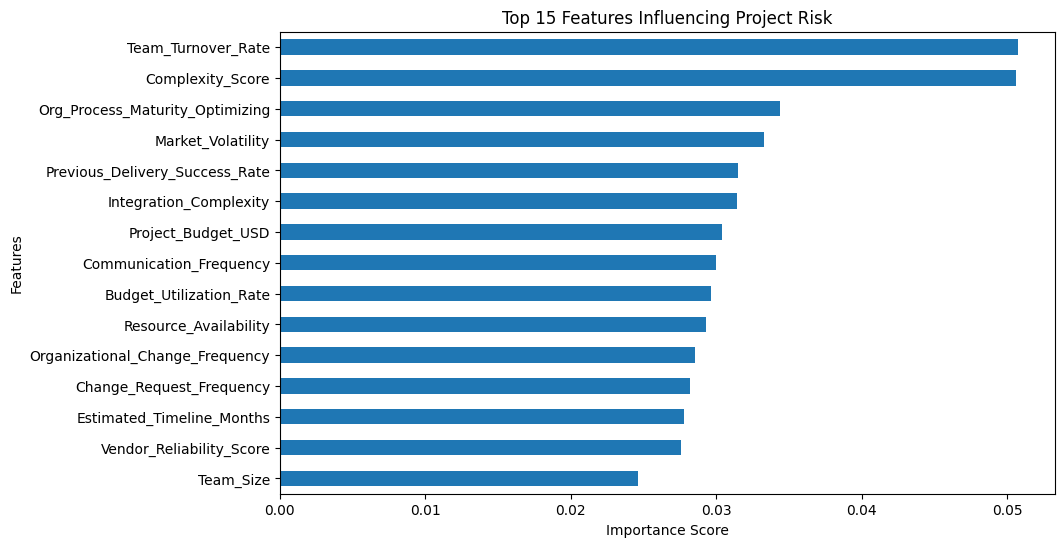

In [ ]:
top_features.sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Top 15 Features Influencing Project Risk")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [ ]:
df_encoded.to_csv("cleaned_project_risk_dataset.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


Class distribution:
Risk_Level
2    1396
0    1036
1     806
Name: count, dtype: int64


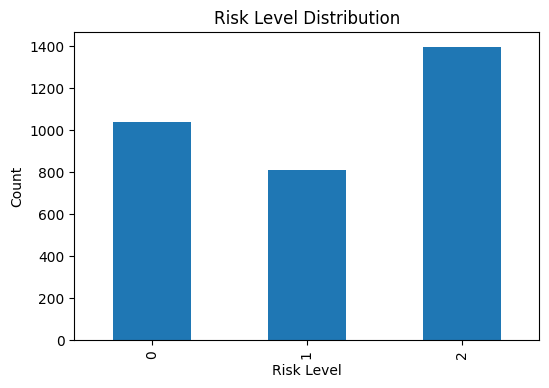

In [ ]:
import matplotlib.pyplot as plt

print("Class distribution:")
print(y.value_counts())

y.value_counts().sort_index().plot(kind="bar", figsize=(6,4))
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

results = {}

# Logistic Regression
lr_model = LogisticRegression(max_iter=2000, class_weight="balanced")
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

results["Logistic Regression"] = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(results["Logistic Regression"], 4))
print(classification_report(y_test, lr_pred, target_names=label_encoder.classes_))

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

results["Random Forest"] = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(results["Random Forest"], 4))
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.4707
              precision    recall  f1-score   support

        High       0.49      0.57      0.53       207
         Low       0.43      0.66      0.52       161
      Medium       0.49      0.29      0.37       280

    accuracy                           0.47       648
   macro avg       0.47      0.51      0.47       648
weighted avg       0.48      0.47      0.46       648

Random Forest Accuracy: 0.5448
              precision    recall  f1-score   support

        High       0.62      0.39      0.48       207
         Low       0.65      0.42      0.51       161
      Medium       0.49      0.73      0.59       280

    accuracy                           0.54       648
   macro avg       0.59      0.51      0.53       648
weighted avg       0.57      0.54      0.53       648



                     Accuracy
Random Forest        0.544753
Logistic Regression  0.470679


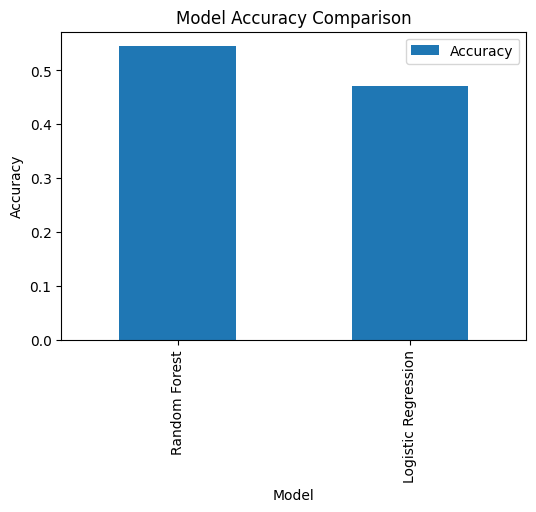

In [ ]:
comparison_df = pd.DataFrame.from_dict(results, orient="index", columns=["Accuracy"])
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False)

print(comparison_df)

comparison_df.plot(kind="bar", figsize=(6,4))
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.553911423230301


In [ ]:
best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)

best_rf_accuracy = accuracy_score(y_test, best_rf_pred)

print("Tuned Random Forest Accuracy:", round(best_rf_accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test, best_rf_pred, target_names=label_encoder.classes_))

Tuned Random Forest Accuracy: 0.5617

Classification Report:
              precision    recall  f1-score   support

        High       0.60      0.49      0.54       207
         Low       0.59      0.57      0.58       161
      Medium       0.53      0.61      0.57       280

    accuracy                           0.56       648
   macro avg       0.57      0.56      0.56       648
weighted avg       0.57      0.56      0.56       648



Complexity_Score                   0.056262
Team_Turnover_Rate                 0.053287
Org_Process_Maturity_Optimizing    0.043867
Previous_Delivery_Success_Rate     0.032076
Market_Volatility                  0.031481
Integration_Complexity             0.031083
Resource_Availability              0.030229
Communication_Frequency            0.029514
Organizational_Change_Frequency    0.028975
Project_Budget_USD                 0.028376
Change_Request_Frequency           0.028014
Estimated_Timeline_Months          0.027413
Budget_Utilization_Rate            0.027385
Vendor_Reliability_Score           0.026086
Team_Size                          0.022959
dtype: float64


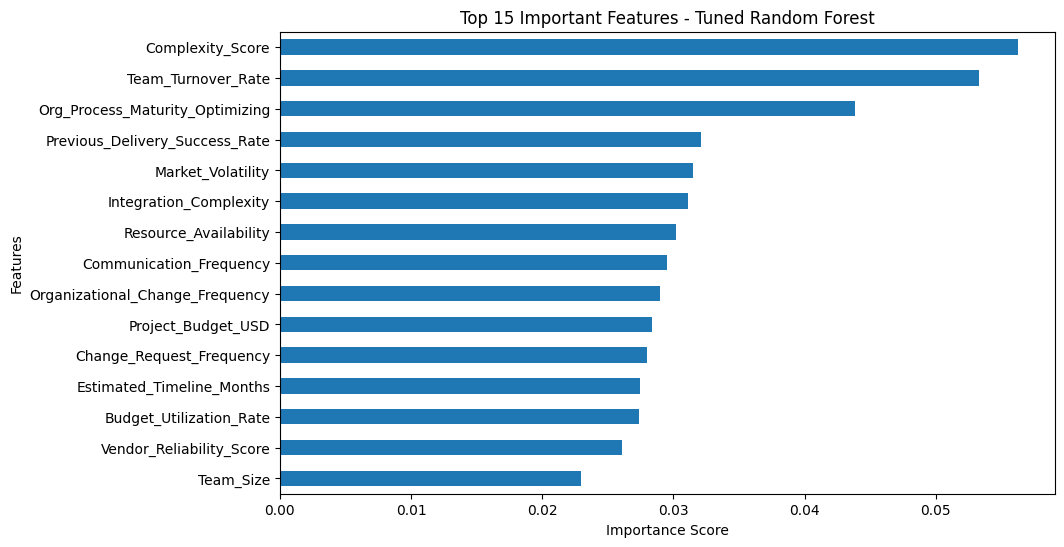

In [ ]:
feature_importance = pd.Series(best_rf.feature_importances_, index=X.columns)
top_features = feature_importance.sort_values(ascending=False).head(15)

print(top_features)

top_features.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Top 15 Important Features - Tuned Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", round(xgb_accuracy, 4))
print(classification_report(y_test, xgb_pred, target_names=label_encoder.classes_))

XGBoost Accuracy: 0.5849
              precision    recall  f1-score   support

        High       0.62      0.47      0.53       207
         Low       0.72      0.52      0.60       161
      Medium       0.53      0.71      0.60       280

    accuracy                           0.58       648
   macro avg       0.62      0.57      0.58       648
weighted avg       0.61      0.58      0.58       648



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (reduce noise)
pca = PCA(n_components=30)  # reduce to 30 features
X_pca = pca.fit_transform(X_scaled)

# Split again
X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# Train XGBoost again
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train_pca, y_train)

y_pred_pca = xgb_model.predict(X_test_pca)

from sklearn.metrics import accuracy_score
print("XGBoost with PCA Accuracy:", accuracy_score(y_test, y_pred_pca))

XGBoost with PCA Accuracy: 0.44598765432098764


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Improved XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Improved XGBoost Accuracy: 0.5925925925925926

Classification Report:

              precision    recall  f1-score   support

        High       0.66      0.50      0.57       207
         Low       0.70      0.50      0.58       161
      Medium       0.53      0.72      0.61       280

    accuracy                           0.59       648
   macro avg       0.63      0.57      0.59       648
weighted avg       0.61      0.59      0.59       648



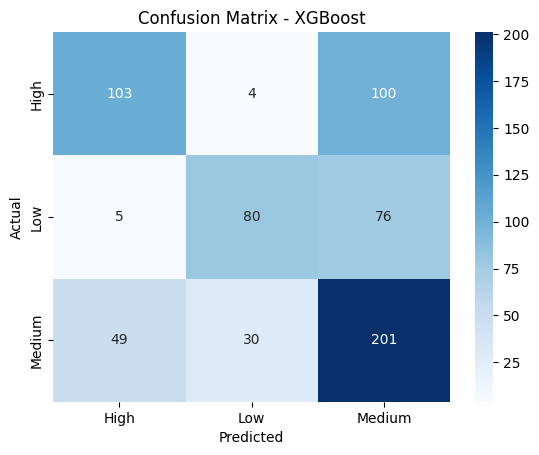

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()